# SUPPORT VECTOR MACHINE

In [17]:
import pandas as pd

# Load dataset
df = pd.read_csv("Pharma_Industry.csv")

# View first rows
print(df.head())

# Dataset shape (rows, columns)
print("Shape:", df.shape)

# Data types and info
print(df.info())

# Summary statistics
print(df.describe())

# Check missing values
print(df.isnull().sum())

   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  
Shape: (500, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (tot

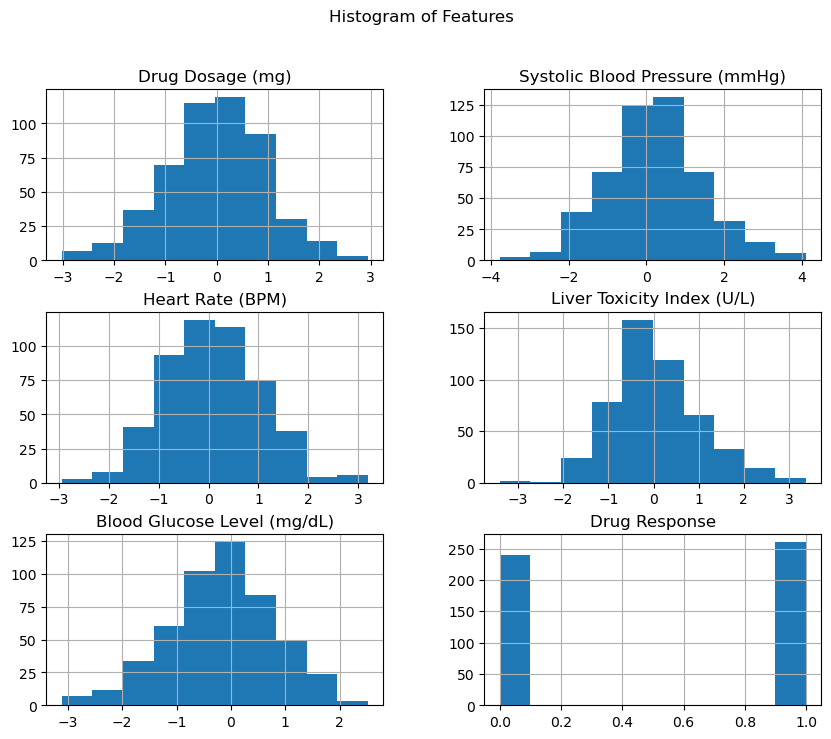

In [18]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.suptitle("Histogram of Features")
plt.show()

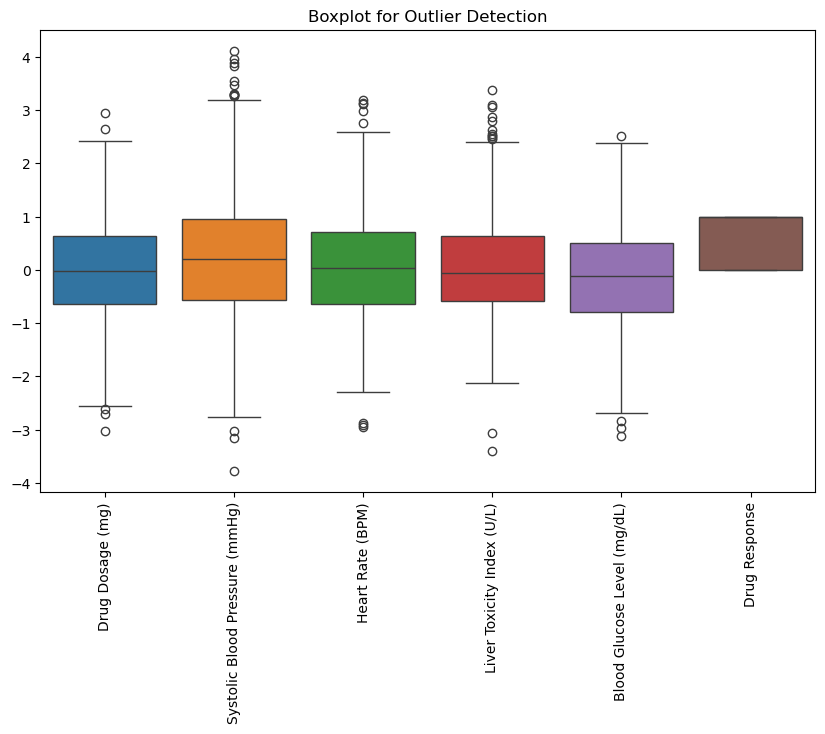

In [19]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

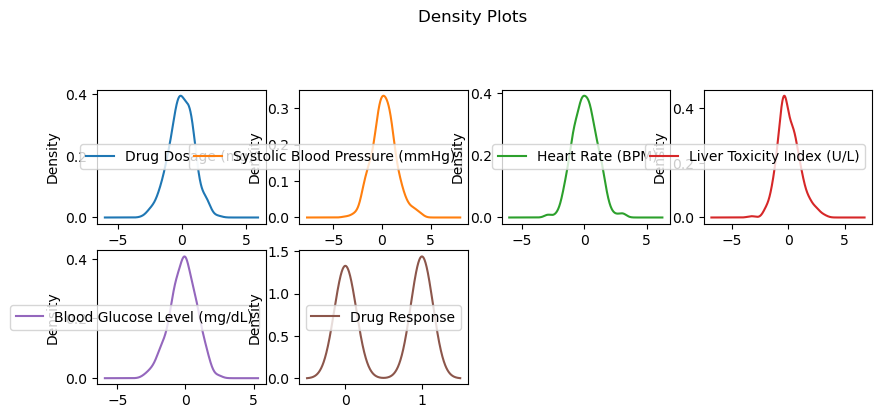

In [20]:
df.plot(kind='density', subplots=True, layout=(4,4), figsize=(10,8), sharex=False)
plt.suptitle("Density Plots")
plt.show()

In [21]:
corr = df.corr()
print(corr)

                                Drug Dosage (mg)  \
Drug Dosage (mg)                        1.000000   
Systolic Blood Pressure (mmHg)          0.090618   
Heart Rate (BPM)                        0.040571   
Liver Toxicity Index (U/L)              0.128127   
Blood Glucose Level (mg/dL)             0.012434   
Drug Response                           0.043457   

                                Systolic Blood Pressure (mmHg)  \
Drug Dosage (mg)                                      0.090618   
Systolic Blood Pressure (mmHg)                        1.000000   
Heart Rate (BPM)                                     -0.039195   
Liver Toxicity Index (U/L)                            0.283672   
Blood Glucose Level (mg/dL)                           0.037228   
Drug Response                                         0.305226   

                                Heart Rate (BPM)  Liver Toxicity Index (U/L)  \
Drug Dosage (mg)                        0.040571                    0.128127   
Systolic Blo

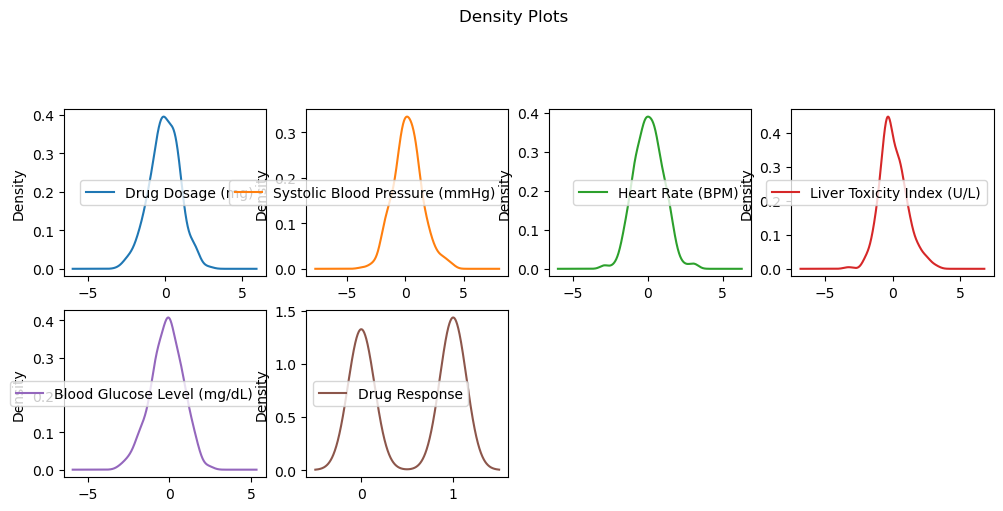

In [22]:
df.plot(kind='density', subplots=True, layout=(4,4), figsize=(12,10), sharex=False)
plt.suptitle("Density Plots")
plt.show()

In [23]:
corr = df.corr()
print(corr)

                                Drug Dosage (mg)  \
Drug Dosage (mg)                        1.000000   
Systolic Blood Pressure (mmHg)          0.090618   
Heart Rate (BPM)                        0.040571   
Liver Toxicity Index (U/L)              0.128127   
Blood Glucose Level (mg/dL)             0.012434   
Drug Response                           0.043457   

                                Systolic Blood Pressure (mmHg)  \
Drug Dosage (mg)                                      0.090618   
Systolic Blood Pressure (mmHg)                        1.000000   
Heart Rate (BPM)                                     -0.039195   
Liver Toxicity Index (U/L)                            0.283672   
Blood Glucose Level (mg/dL)                           0.037228   
Drug Response                                         0.305226   

                                Heart Rate (BPM)  Liver Toxicity Index (U/L)  \
Drug Dosage (mg)                        0.040571                    0.128127   
Systolic Blo

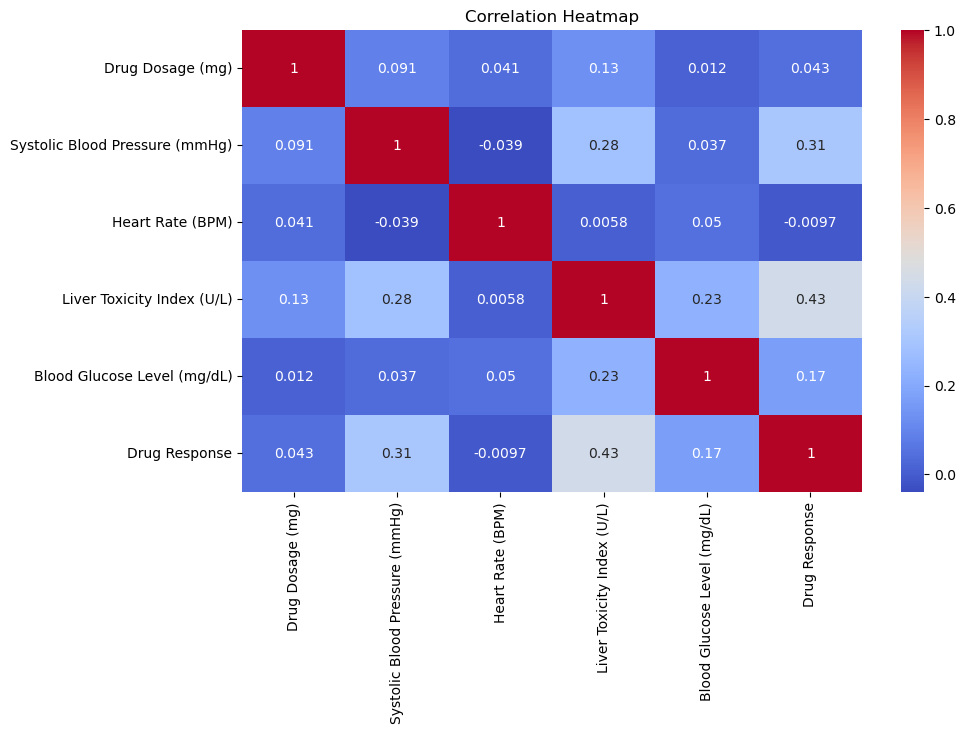

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [26]:
df = pd.get_dummies(df, drop_first=True)
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [27]:
print(df.columns)

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')


In [28]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 80% train, 20% test
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (400, 5)
Testing set: (100, 5)


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

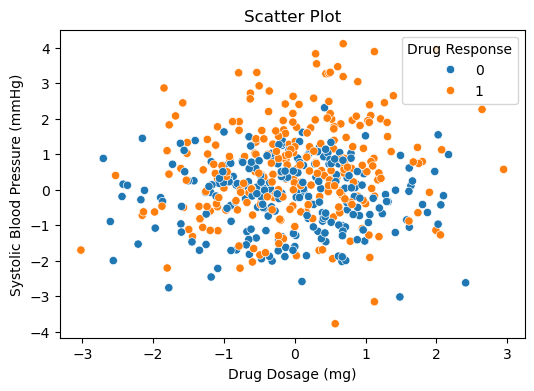

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Replace with your column names
plt.figure(figsize=(6,4))
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1], hue=df['Drug Response'])
plt.title("Scatter Plot")
plt.show()

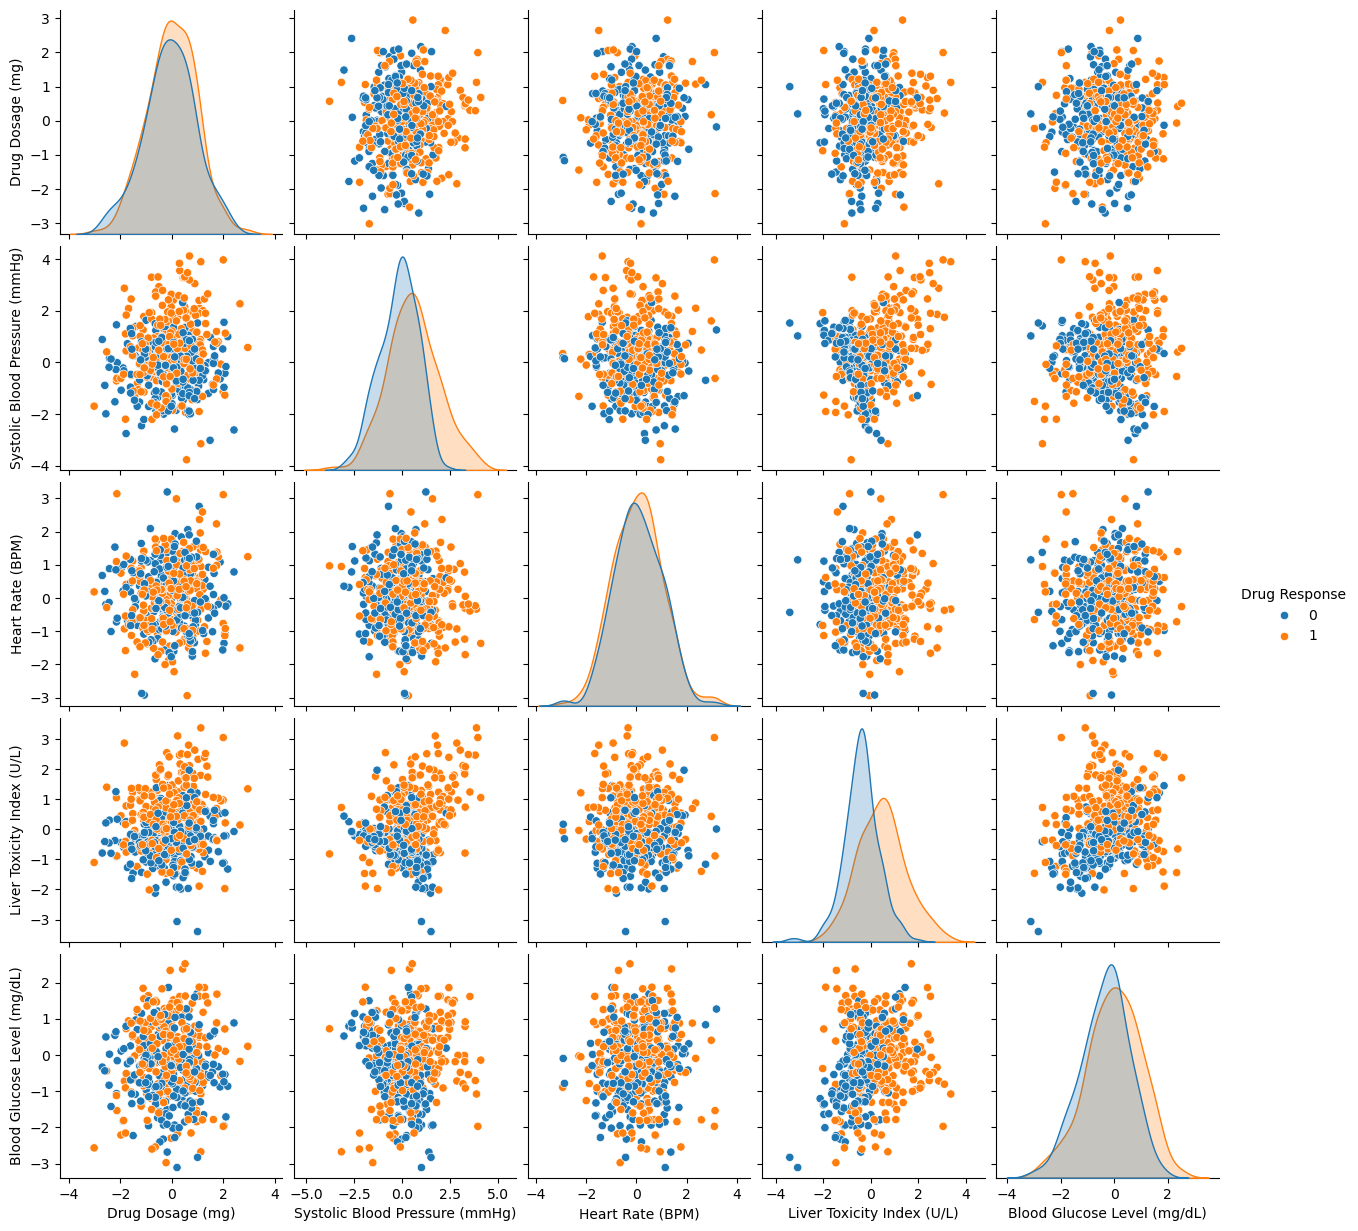

In [32]:
sns.pairplot(df, hue='Drug Response')
plt.show()

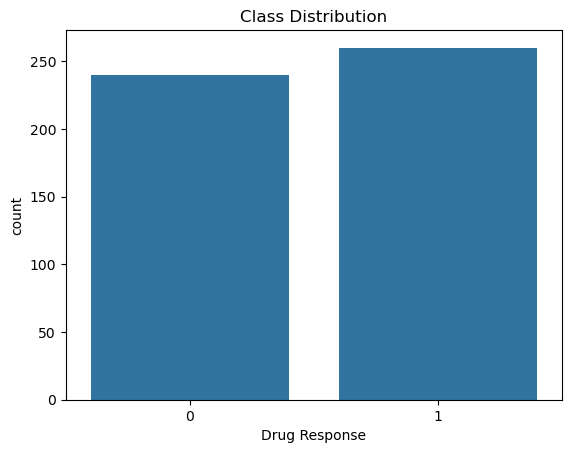

In [34]:
sns.countplot(x='Drug Response', data=df)
plt.title("Class Distribution")
plt.show()

In [36]:
print(df['Drug Response'].value_counts())

Drug Response
1    260
0    240
Name: count, dtype: int64


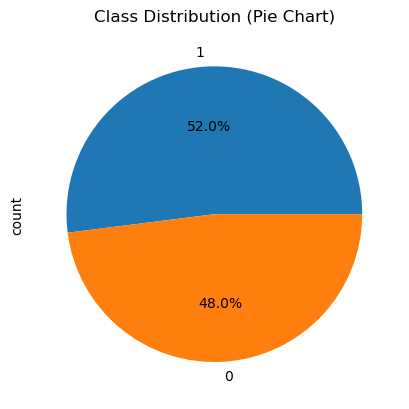

In [38]:
df['Drug Response'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Class Distribution (Pie Chart)")
plt.show()

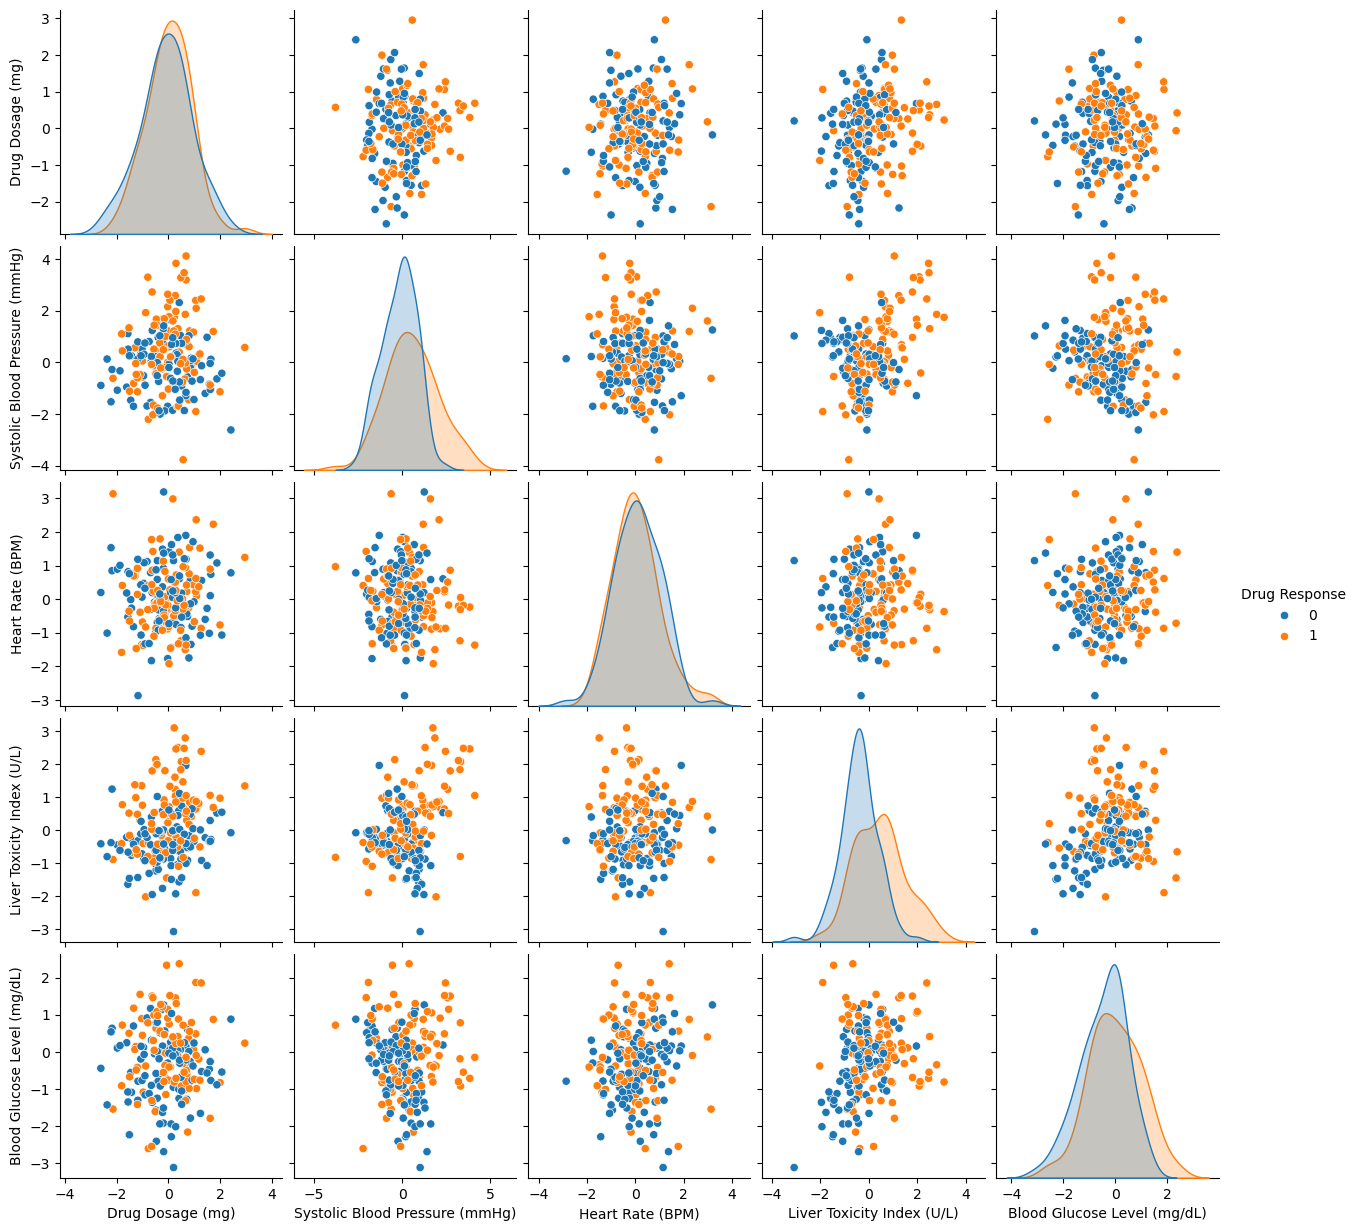

In [39]:
sns.pairplot(df.sample(200), hue='Drug Response')

In [40]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [41]:
# Create SVM model
svm_model = SVC(kernel='rbf')

# Train model
svm_model.fit(X_train, y_train)

SVC()

In [42]:
# Predict on test data
y_pred = svm_model.predict(X_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.84


In [44]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[37  7]
 [ 9 47]]


In [45]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82        44
           1       0.87      0.84      0.85        56

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Select first 2 features
X_vis = X.iloc[:, :2]
y_vis = y

# Split data
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_vis = scaler.fit_transform(X_train_vis)
X_test_vis = scaler.transform(X_test_vis)

In [47]:
model = SVC(kernel='rbf')
model.fit(X_train_vis, y_train_vis)

SVC()

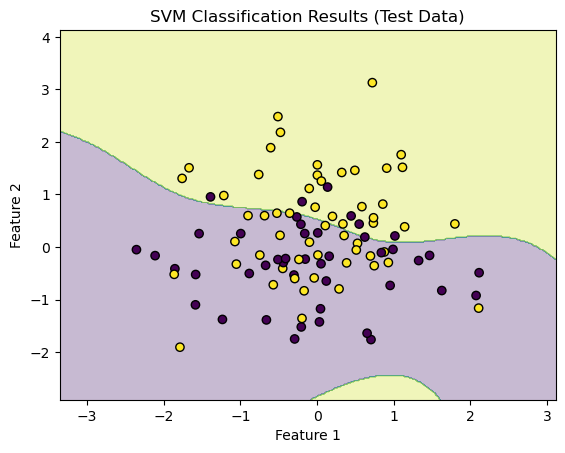

In [48]:
# Create grid
x_min, x_max = X_test_vis[:, 0].min() - 1, X_test_vis[:, 0].max() + 1
y_min, y_max = X_test_vis[:, 1].min() - 1, X_test_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot test points
scatter = plt.scatter(
    X_test_vis[:, 0],
    X_test_vis[:, 1],
    c=y_test_vis,
    edgecolor='k'
)

plt.title("SVM Classification Results (Test Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

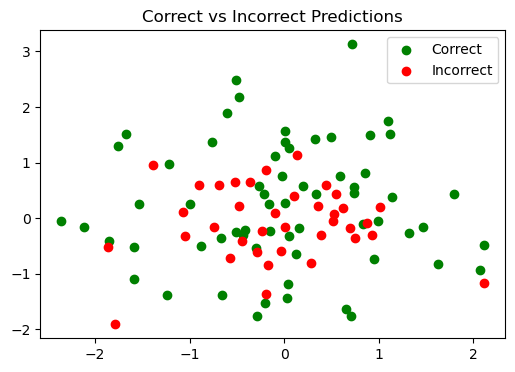

In [49]:
y_pred = model.predict(X_test_vis)

plt.figure(figsize=(6,4))

# Correct predictions
correct = y_pred == y_test_vis
plt.scatter(X_test_vis[correct, 0], X_test_vis[correct, 1],
            color='green', label='Correct')

# Incorrect predictions
incorrect = y_pred != y_test_vis
plt.scatter(X_test_vis[incorrect, 0], X_test_vis[incorrect, 1],
            color='red', label='Incorrect')

plt.legend()
plt.title("Correct vs Incorrect Predictions")
plt.show()

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define parameter grid
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

# Create GridSearch model
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,              # 5-fold cross validation
    scoring='accuracy',
    verbose=2
)

# Train model
grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy', verbose=2)

In [51]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [53]:
best_model = grid.best_estimator_
best_model

SVC(C=1)

In [54]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_best = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Optimized Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        44
           1       0.87      0.84      0.85        56

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



In [55]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    SVC(),
    param_grid,
    n_iter=10,
    cv=5,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

Best Params: {'kernel': 'rbf', 'gamma': 'auto', 'C': 10}


In [56]:
# Old model accuracy
print("Old Accuracy:", accuracy_score(y_test, y_pred))

# New model accuracy
print("New Accuracy:", accuracy_score(y_test, y_pred_best))

Old Accuracy: 0.63
New Accuracy: 0.84


In [57]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Different kernels
kernels = ['linear', 'poly', 'rbf']

results = {}

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    
    y_pred_k = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_k)
    
    results[k] = acc
    print(f"{k} Kernel Accuracy: {acc}")

print("\nFinal Comparison:", results)

linear Kernel Accuracy: 0.78
poly Kernel Accuracy: 0.71
rbf Kernel Accuracy: 0.84

Final Comparison: {'linear': 0.78, 'poly': 0.71, 'rbf': 0.84}


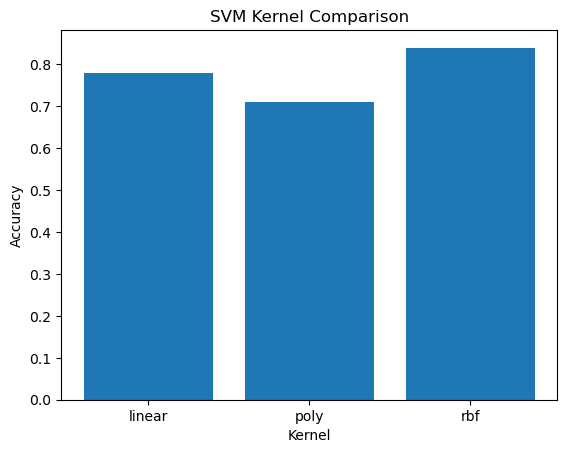

In [58]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("SVM Kernel Comparison")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
3.
Predict whether a patient will respond to a drug
Helps in personalized medicine
Reduces cost of clinical trials
#other application
Medical diagnosis (cancer detection)
Spam email classification
Image classification
💳Fraud detection